#NYC Airbnb Data: Advanced Cleaning & Preliminary Insights

Importing libraries, and reading file.

In [31]:
# importing pandas:
import pandas as pd
import matplotlib.pyplot as plt

# reading the file:
df = pd.read_csv('/content/AB_NYC_2019.csv')

Here we're making a preview of the data, to get an idea about missing values, number of columns, data types, rows, columns.

In [32]:
# exploring the data:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

To make sure of the lengh(rows), width(columns), we use ".shape" atrribute.

In [33]:
# DataFrame shape:
df.shape

(48895, 16)

Here we've checked the columns content: id, name, etc.

In [34]:
# the dataset columns:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

Here we're taking the DataFrame (data) head, to get an idea about how it looks.

In [35]:
# a sample of the dataset:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


By summing missing values in each column, we can start cleaning the dirty data !

In [36]:
# missing values:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


We have no idea how to replace missing names, host_names, so we're going to fill them by: "Unknown", in order to keep data preserved.

In [37]:
# replacing columns missing values: [name, host_name]
df['name'] = df['name'].fillna('Unknown')
df['host_name'] = df['host_name'].fillna('Unknown')

Work done well !

In [38]:
# making sure that data are filled with unknown:
df[['name', 'host_name']].isnull().sum()

,0
name,0
host_name,0


After checking the DataFrame, we noticed that every missing value in the "reviews_per_month" column, was because of the zeros in the "number_of_reviews", so we had to replace gaps with zeros !

In [39]:
# setting zeros to 'reviews_per_month' column:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

Work done well !

In [40]:
# # making sure that data are filled with unknown:
df['reviews_per_month'].isnull().sum()

np.int64(0)

We are facing a big problem ! which is outliers. The maximum value is 10k\$, but the mean is only 151.2\$. And it's not logical to have a minimum value of 0\$ !

In [41]:
# checking the range of price:
df['price'].describe()

,price
count,48895.000000
mean,152.720687
std,240.154170
min,0.000000
25%,69.000000
50%,106.000000
75%,175.000000
max,10000.000000


Here we're dropping two unnecessary columns, which won't affect in any analysis or prediction models.

In [42]:
# deleting unnecessary columns:
df = df.drop(['id', 'host_id'], axis=1)

Filtering the DataFrame by dropping columns with 0\$ pricing.

In [43]:
# deleting rows with price: 0$
df = df[df['price'] != 0]

--- Outlier Removal using Interquartile Range (IQR) ---

Purpose: Clean the price column by removing extreme outliers and zero values.

Methodology: Calculated the Upper Fence (Q3 + 1.5 * IQR) to define the logical price limit.

Impact: Improved data quality and ensured a more accurate mean for analysis.

In [44]:
# keeping the heart of the data:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + (1.5 * IQR)

Filtering the data again, to discard outliers out of our dataset.

In [45]:
# filtering outliers:
df = df[(df['price'] > 0) & (df['price'] < upper_fence)]

Finally, we have a logical number right here!

In [46]:
# the new distribution of prices:
df['price'].describe()

,price
count,45907.000000
mean,119.975755
std,68.100096
min,10.000000
25%,65.000000
50%,100.000000
75%,159.000000
max,333.000000


As we said before, the "last_review" column is also affected by the "number_of_reviews" column, but here we're replacing missing dates by old dates to keep the unity of the data type, and to make it easy for model to understand that it's a falsy value.

In [47]:
df['last_review'] = df['last_review'].fillna('1900-01-01')

In [48]:
# transforming dates:
df['last_review'] = pd.to_datetime(df['last_review'])

Now it's aggegation turn to explore unique patterns in this dataset!

In [49]:
df.groupby('neighbourhood_group')[['price', 'availability_365', 'number_of_reviews']].mean()

,price,availability_365,number_of_reviews
neighbourhood_group,,,
Bronx,77.437792,164.599626,26.314312
Brooklyn,105.748634,98.484335,24.508606
Manhattan,145.912103,105.843128,21.955282
Queens,88.904437,143.019041,27.971798
Staten Island,89.235616,199.893151,31.605479


Summary of Findings:

Brooklyn shows the highest demand with the lowest availability (average ~98 days), making it the most competitive area for guests.

Manhattan remains the premium choice with the highest average price ($145.9), yet maintains more availability than Brooklyn.

The Bronx offers the most budget-friendly accommodations at an average of $77.4.

Staten Island appears to have the most "reviewed" listings on average, suggesting high guest engagement despite its distance from the city center.

checking how much the shape of the DataFrame decreased.

In [50]:
# the shape final DataFrame:
df.shape

(45907, 14)

Final result:

In [ ]:
df.head()

Saving the clean DataFrame

In [51]:
# saving the clean DataFrame:
df.to_csv('Clean_Data.csv')

Visualizing data:
- Relation between the number of reviews & prices
- Relation between availability & prices

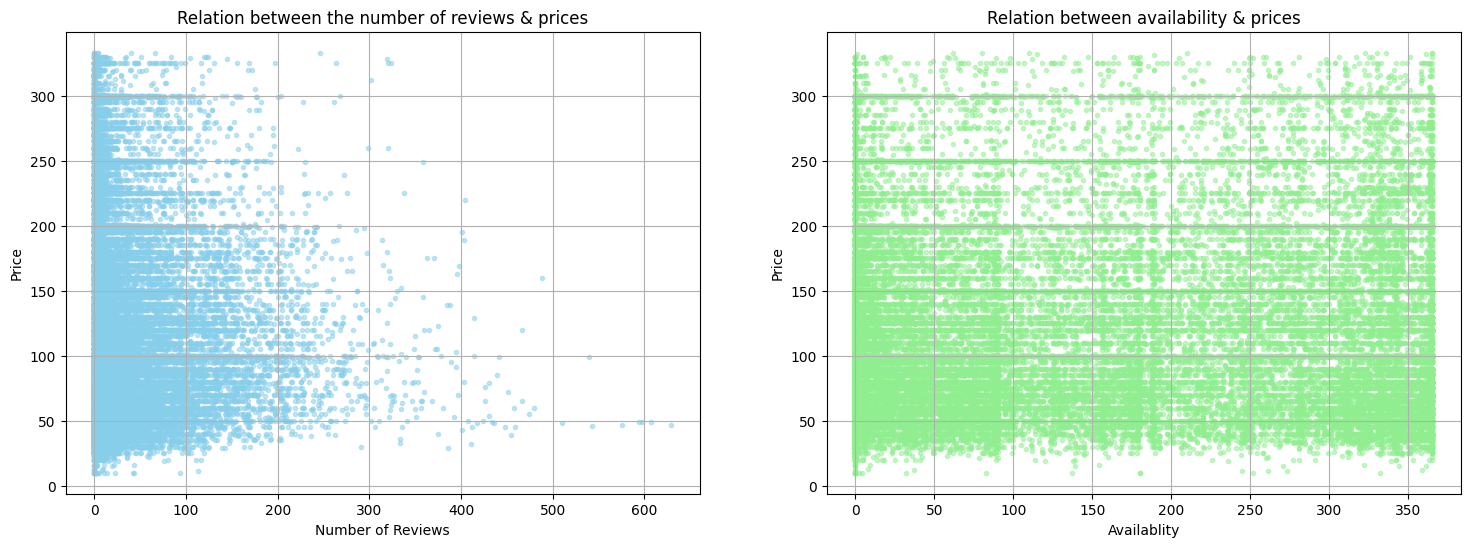

In [69]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

ax1.scatter(df['number_of_reviews'], df['price'], alpha=0.5, color='skyblue', marker='.')
ax1.set_title('Relation between the number of reviews & prices')
ax1.set_xlabel('Number of Reviews')
ax1.set_ylabel('Price')
ax1.grid(True)

ax2.scatter(df['availability_365'], df['price'], alpha=0.5, color='lightgreen', marker='.')
ax2.set_title('Relation between availability & prices')
ax2.set_xlabel('Availablity')
ax2.set_ylabel('Price')
ax2.grid(True)

plt.show()